In [1]:
import os
from collections import defaultdict

import numpy as np
from astropy.io import fits
import pandas as pd

from astropy.convolution import convolve
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.psf import IntegratedGaussianPRF

In [2]:
def load_focusing_images(base_dir, target_group_ids=None, prefix="focustest_gcode4_5000_20250915_"):
    from collections import defaultdict
    import os
    import numpy as np
    from astropy.io import fits

    group_dict = defaultdict(lambda: {"fits": [], "meta": None})

    for fname in os.listdir(base_dir):
        if prefix is not None and (not fname.startswith(prefix)):
            continue

        fpath = os.path.join(base_dir, fname)
        base, ext = os.path.splitext(fname)
        parts = fname.split("_")
        group_id = parts[-2]

        if ext == ".fits":
            idx_str = os.path.splitext(parts[-1])[0]
            idx = int(idx_str)
            group_dict[group_id]["fits"].append((idx, fpath))
        elif fname.endswith("_meta.json"):
            group_dict[group_id]["meta"] = fpath

    for gid, entry in group_dict.items():
        entry["fits"].sort(key=lambda x: x[0])

    images_dict = {}
    meta_dict = {}

    for gid, entry in group_dict.items():
        if (target_group_ids is not None) and (gid not in target_group_ids):
            continue

        image_list = []
        for idx, fpath in entry["fits"]:
            print(f"[{gid}] Loading idx={idx}: {fpath}")
            with fits.open(fpath) as hdul:
                image_list.append(hdul[1].data)

        if image_list:
            images_dict[gid] = np.array(image_list)

        meta_dict[gid] = entry["meta"]

    return images_dict, meta_dict

In [3]:
base_dir = "./FOCUSING_20250915"
target_group_ids = [
 '00000', '00003', '00004', '00005', '00006',
 '00007', '00008', '00009', '00010', '00011', '00012'
]
#特に指定しない場合はtarget_group_ids=target_group_idsを消す。
images_dict, meta_dict = load_focusing_images(base_dir, target_group_ids=target_group_ids)

[00008] Loading idx=0: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_0.fits
[00008] Loading idx=1: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_1.fits
[00008] Loading idx=2: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_2.fits
[00008] Loading idx=3: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_3.fits
[00008] Loading idx=4: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_4.fits
[00008] Loading idx=5: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00008_5.fits
[00007] Loading idx=0: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00007_0.fits
[00007] Loading idx=1: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00007_1.fits
[00007] Loading idx=2: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00007_2.fits
[00007] Loading idx=3: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00007_3.fits
[00007] Loading idx=4: ./FOCUSING_20250915/focustest_gcode4_5000_20250915_00007_4.fits
[00007] Loading idx=5: ./FOCUSING_20250915/

In [4]:
print(images_dict.keys())

dict_keys(['00008', '00007', '00006', '00010', '00012', '00011', '00000', '00009', '00003', '00005', '00004'])


In [5]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np


def _bin2d_mean(img, bin_factor):
    """
    2D 画像を bin_factor x bin_factor ごとに平均して縮小する。
    （端が割り切れない分は切り捨て）
    """
    if bin_factor <= 1:
        return img

    ny, nx = img.shape
    by = (ny // bin_factor) * bin_factor
    bx = (nx // bin_factor) * bin_factor

    img_cropped = img[:by, :bx]

    # (ny, nx) -> (by/bin, bin, bx/bin, bin) -> 平均
    img_binned = img_cropped.reshape(
        by // bin_factor, bin_factor,
        bx // bin_factor, bin_factor
    ).mean(axis=(1, 3))

    return img_binned


def show_focus_group_fast(image_dict, group_id,
                          vmin=75, vmax=150,
                          bin_factor=6):
    """
    image_dict[group_id] 内の画像を 1xN グリッドで表示（高速版）。

    - 描画前に bin_factor x bin_factor 平均で縮小してから imshow
    - 巨大な CMOS 画像でもそれなりに軽く表示できる

    Parameters
    ----------
    image_dict : dict
        {group_id: np.ndarray(shape=(N, H, W))} の辞書
    group_id : str
        表示したい group_id
    vmin, vmax : float
        imshow の表示レンジ（元の関数と同じ）
    bin_factor : int
        縦横でこの factor だけ縮小（4 → ピクセル数 1/16）
    """

    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found.")
        return

    image_list = image_dict[group_id]   # shape = (N, H, W)
    n_images = len(image_list)

    # --- Figure レイアウト ---
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    # --- 画像ごとの描画（縮小してから表示） ---
    for i, ax in enumerate(axs):
        ax.set_title(f"CMOS {i}", ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])

        img = image_list[i]
        img_binned = _bin2d_mean(img, bin_factor)

        ax.imshow(img_binned, vmin=vmin, vmax=vmax,
                  origin='lower', cmap='gray',
                  interpolation='nearest')  # 補間も軽め

    plt.show()


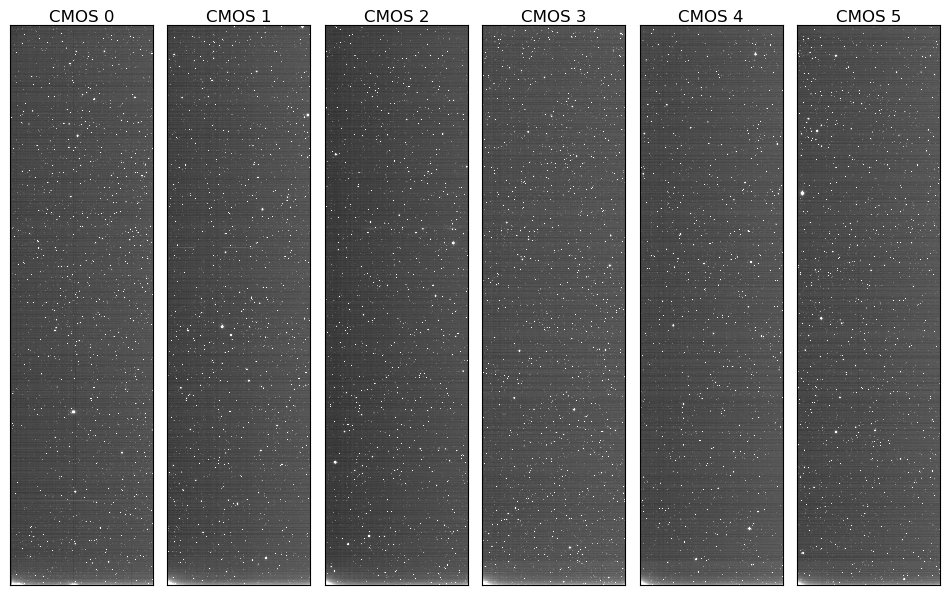

In [6]:
show_focus_group_fast(images_dict, "00012")

In [7]:
import numpy as np
import pandas as pd

from astropy.convolution import convolve
from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.psf import CircularGaussianSigmaPRF


def detection_random_patches(
    data,
    nrows,
    ncols,
    sigma=5.0,
    threshold_sigma=5.0,
    pixel_scale=0.23,
    n_patches=3,
    patch_frac_y=0.25,
    patch_frac_x=0.25,
    rng_seed=None,
    max_trials=100,
):
    """
    1枚の CMOS 画像 data に対して、
    「互いに重ならない」ランダムパッチを最大 n_patches 個切り出して detection を行う。

    Parameters
    ----------
    data : 2D ndarray
        画像データ (ny, nx)
    nrows, ncols : int
        （今は未使用。将来 grid_id 等を復活させるならここで利用）
    sigma : float
        PSF Gaussian の sigma [pix]
    threshold_sigma : float
        背景 RMS に対する detection 閾値 (N sigma)
    pixel_scale : float
        [arcsec / pix]
    n_patches : int
        切り出したいパッチ数（重ならない範囲で最大）
    patch_frac_y, patch_frac_x : float
        元画像に対するパッチサイズの割合（0.25 → 縦横 25%）
    rng_seed : int or None
        乱数シード。None のときは毎回ランダム。
    max_trials : int
        1パッチを選ぶ際に「非重複候補」を探す最大試行回数。
        それでもダメなら、その時点で打ち切る。

    Returns
    -------
    segm_list : list
        各パッチでの SegmentationImage（何も検出されなければ空リストもあり）
    cat_list : list
        各パッチでの SourceCatalog
    det_all : pandas.DataFrame
        すべてのパッチで検出した天体をまとめた表。
        xcentroid, ycentroid は元画像座標に変換済み。
        patch_id 列でどのパッチ由来か識別可能。
    """

    ny, nx = data.shape

    # パッチサイズ（最低 10x10）
    ph = max(int(ny * patch_frac_y), 10)
    pw = max(int(nx * patch_frac_x), 10)

    if ph > ny or pw > nx:
        # 画像より大きくなってしまう場合は全画像を1パッチ扱い
        ph, pw = ny, nx

    rng = np.random.default_rng(rng_seed)

    segm_list = []
    cat_list = []
    df_list = []

    # 既に確保したパッチ矩形を保存: [(y0,y1,x0,x1), ...]
    used_boxes = []

    def is_overlapping(y0, y1, x0, x1, boxes):
        """既存の boxes と (y0,y1,x0,x1) が重なるかどうか。"""
        for (oy0, oy1, ox0, ox1) in boxes:
            # 軸ごとに「区間がかぶっている」かチェック
            # 一点でもかぶっていたら重なりとみなす
            if not (x1 <= ox0 or x0 >= ox1 or y1 <= oy0 or y0 >= oy1):
                return True
        return False

    # -------------------------------
    # 互いに重ならない n_patches 個を試みる
    # -------------------------------
    for pid in range(n_patches):
        found = False
        for _ in range(max_trials):
            if ny == ph:
                y0 = 0
            else:
                y0 = int(rng.integers(0, ny - ph + 1))
            if nx == pw:
                x0 = 0
            else:
                x0 = int(rng.integers(0, nx - pw + 1))

            y1 = y0 + ph
            x1 = x0 + pw

            if not is_overlapping(y0, y1, x0, x1, used_boxes):
                used_boxes.append((y0, y1, x0, x1))
                found = True
                break

        if not found:
            # これ以上重ならないパッチを作れないので打ち切り
            print(f"[warning] could only place {pid} non-overlapping patches (requested {n_patches})")
            break

        # -------------------------------
        # このパッチで detection 実行
        # -------------------------------
        sub = data[y0:y1, x0:x1]

        # 背景推定はパッチごと
        bkg = Background2D(
            sub,
            box_size=50,
            filter_size=3,
            bkg_estimator=MedianBackground()
        )
        sub_sub = sub - bkg.background

        # PSF smoothing
        psf_model = CircularGaussianSigmaPRF(sigma=sigma)
        yy, xx = np.mgrid[-5:6, -5:6]
        psf = psf_model(xx, yy)
        psf /= np.sum(psf)
        smoothed = convolve(sub_sub, psf)

        # detection
        threshold = threshold_sigma * bkg.background_rms_median
        segm = detect_sources(smoothed, threshold, npixels=5)

        if segm is None or segm.nlabels == 0:
            # このパッチでは何も検出されなかった
            print(f"patch {pid}: no sources detected at (x0={x0}, y0={y0})")
            continue

        cat = SourceCatalog(sub_sub, segm)

        a_sigma = cat.semimajor_sigma.value
        b_sigma = cat.semiminor_sigma.value
        sigma_mean = np.sqrt(a_sigma * b_sigma)
        fwhm_pix = sigma_mean * (2 * np.sqrt(2 * np.log(2)))
        fwhm_arcsec = fwhm_pix * pixel_scale
        pa_rad = cat.orientation.to("rad").value
        pa_deg = np.degrees(pa_rad)

        det = pd.DataFrame({
            "ID": np.arange(1, len(cat) + 1),
            "xcentroid": cat.xcentroid,
            "ycentroid": cat.ycentroid,
            "segment_flux": cat.segment_flux,
            "a_sigma": a_sigma,
            "b_sigma": b_sigma,
            "fwhm_pix": fwhm_pix,
            "fwhm_arcsec": fwhm_arcsec,
            "b/a": b_sigma / a_sigma,
            "pa_deg": pa_deg,
        })

        # パッチ内座標 → 元画像座標に変換
        det["xcentroid"] = det["xcentroid"] + x0
        det["ycentroid"] = det["ycentroid"] + y0

        det["patch_id"] = pid

        segm_list.append(segm)
        cat_list.append(cat)
        df_list.append(det)

        print(f"patch {pid}: detected {len(det)} sources at (x0={x0}, y0={y0})")

    # -------------------------------
    # 全パッチのテーブルを結合
    # -------------------------------
    if len(df_list) == 0:
        det_all = pd.DataFrame(
            columns=[
                "ID", "xcentroid", "ycentroid", "segment_flux",
                "a_sigma", "b_sigma", "fwhm_pix", "fwhm_arcsec",
                "b/a", "pa_deg", "patch_id"
            ]
        )
    else:
        det_all = pd.concat(df_list, ignore_index=True)

    return segm_list, cat_list, det_all


In [8]:
from dask import delayed
from dask.distributed import get_client, as_completed
from tqdm.auto import tqdm
import numpy as np


def run_detection_on_all_dask_random_patches(
    image_dict,
    nrows,
    ncols,
    sigma=5.0,
    threshold_sigma=5.0,
    pixel_scale=0.23,
    n_patches=3,
    patch_frac_y=0.25,
    patch_frac_x=0.25,
    rng_seed=None,
):
    """
    image_dict 内のすべての group_id / frame について、
    各フレームの画像からランダムパッチを複数個切り出し、
    その中だけで detection を行う（Dask distributed 版）。

    各 CMOS フレームごとに「異なる」乱数シードを使って
    ランダム領域を選ぶようにしてある。

    Parameters
    ----------
    rng_seed : int or None
        全体の再現性をコントロールするためのシード。
        - None の場合：各フレームは独立に乱数（非再現）
        - int の場合：フレームごとに異なるシードを
          グローバル RNG から切り出して渡す（再現可能）

    Returns
    -------
    detection_results : dict
        detection_results[group_id] = [
            {
                "index": idx,        # CMOS 番号
                "segm": segm_list,   # 各パッチの SegmentationImage のリスト
                "catalog": cat_list, # 各パッチの SourceCatalog のリスト
                "table": det_all,    # 全パッチ結合 DataFrame
            },
            ...
        ]
    """

    client = get_client()

    delayed_tasks = []
    keys = []  # (gid, idx)

    # --- グローバル RNG：ここから各フレーム用 seed を切り出す ---
    if rng_seed is not None:
        global_rng = np.random.default_rng(rng_seed)
    else:
        global_rng = None

    for gid, imgs in image_dict.items():
        for idx, img in enumerate(imgs):
            keys.append((gid, idx))

            # フレームごとに別のシードを割り当てる
            if global_rng is not None:
                # 0〜2^32-1 の範囲で一つ引く
                child_seed = int(global_rng.integers(0, 2**32 - 1))
            else:
                # None を渡せば detection_random_patches 側が勝手にランダム化
                child_seed = None

            task = delayed(detection_random_patches)(
                img,
                nrows=nrows,
                ncols=ncols,
                sigma=sigma,
                threshold_sigma=threshold_sigma,
                pixel_scale=pixel_scale,
                n_patches=n_patches,
                patch_frac_y=patch_frac_y,
                patch_frac_x=patch_frac_x,
                rng_seed=child_seed,    # ← ここがフレームごとに違う
            )
            delayed_tasks.append(task)

    print(f"Total tasks: {len(delayed_tasks)}")

    futures = client.compute(delayed_tasks)
    future_to_key = {fut: key for fut, key in zip(futures, keys)}

    detection_results = {}

    for fut in tqdm(as_completed(futures), total=len(futures)):
        segm_list, cat_list, det_all = fut.result()
        gid, idx = future_to_key[fut]

        detection_results.setdefault(gid, []).append({
            "index": idx,
            "segm": segm_list,
            "catalog": cat_list,
            "table": det_all,
        })

    # index 順にソート
    for gid in detection_results:
        detection_results[gid].sort(key=lambda d: d["index"])

    return detection_results


In [9]:
from dask.distributed import Client
import time

client = Client(processes=True, n_workers=14, threads_per_worker=2)
print(client)

nrows, ncols = 4, 5

t0 = time.time()
det_results_patch = run_detection_on_all_dask_random_patches(
    images_dict,
    nrows=nrows,
    ncols=ncols,
    sigma=5.0,
    threshold_sigma=5.0,
    pixel_scale=0.23,
    n_patches=3,          # 各 CMOS フレームにつき 3 パッチ
    patch_frac_y=0.25,
    patch_frac_x=0.25,
    rng_seed=1,        # 再現したいなら seed 固定
)
t1 = time.time()
print(f"\n>>> detection finished in {t1 - t0:.3f} seconds")


/home/satoksk/miniconda3/envs/astro/lib/python3.11/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37255 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:34093' processes=14 threads=28, memory=188.64 GiB>
Total tasks: 66


/home/satoksk/miniconda3/envs/astro/lib/python3.11/site-packages/distributed/client.py:3374: UserWarning: Sending large graph of size 3.15 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


  0%|          | 0/66 [00:00<?, ?it/s]


>>> detection finished in 24.529 seconds


In [11]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

def _bin2d_mean(img, bin_factor):
    """
    2D 画像を bin_factor x bin_factor ごとに平均して縮小する。
    端が割り切れない部分は切り捨て。
    """
    if bin_factor <= 1:
        return img, 0, 0  # (img, y0, x0)

    ny, nx = img.shape
    by = (ny // bin_factor) * bin_factor
    bx = (nx // bin_factor) * bin_factor

    img_cropped = img[:by, :bx]

    img_binned = img_cropped.reshape(
        by // bin_factor, bin_factor,
        bx // bin_factor, bin_factor
    ).mean(axis=(1, 3))

    # 今回は左上基準でしか切ってないので y0=x0=0 を返すが、
    # 将来部分切り出しする場合に備えて返り値に含めておく
    return img_binned, 0, 0


def show_focus_group_with_detections(
    image_dict,
    det_results,
    group_id,
    vmin=75,
    vmax=150,
    s=5,
    bin_factor=1,
):
    """
    すでに計算済みの det_results を使って、
    image_dict[group_id] の各CMOS画像に検出位置を重ねて表示する（高速表示用に binning 対応）。

    Parameters
    ----------
    image_dict : dict
        {group_id: [img0, img1, ...]} の形の辞書
        img は (H, W) np.ndarray
    det_results : dict
        run_detection_on_all_local / run_detection_on_all_dask が返した結果。
        det_results[gid] は各フレームの dict のリストを想定。
        各 dict は
          {
            "index": idx,
            "segm": ...,
            "catalog": ...,
            "table": det_smooth (DataFrame)
          }
        を含む。
    group_id : hashable
        表示したいキー（例: "00012"）
    vmin, vmax : float
        imshow の表示レンジ（全コマで揃える）
    s : float
        検出マーカーのサイズ（scatter の s）
    bin_factor : int
        表示前に画像を bin_factor x bin_factor で平均ビニングする。
        4 → ピクセル数 1/16、描画がかなり軽くなる。
    """

    # --- 存在チェック ---
    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found in image_dict.")
        return

    if group_id not in det_results:
        print(f"Group ID {group_id} was not found in det_results.")
        return

    image_list = image_dict[group_id]     # shape = (N, H, W)
    n_images = len(image_list)

    # det_results[group_id] を index → record の dict にしておく
    frame_results = det_results[group_id]  # list of dicts
    idx_to_record = {rec["index"]: rec for rec in frame_results}

    # --- Figure レイアウト（1 x N グリッド） ---
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    # --- 各CMOSごとに描画 ---
    for i, (img, ax) in enumerate(zip(image_list, axs)):
        ax.set_title(f"CMOS {i}", ha='center', va='center', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

        # 画像本体をビニング（bin_factor=1 のときはそのまま）
        img_binned, y0, x0 = _bin2d_mean(img, bin_factor)

        ax.imshow(
            img_binned,
            vmin=vmin,
            vmax=vmax,
            origin='lower',
            cmap='gray',
            interpolation='nearest',
        )

        # このフレームに対応する detection 結果があればマーカーを描画
        if i in idx_to_record:
            det_smooth = idx_to_record[i]["table"]  # pandas DataFrame
            if len(det_smooth) > 0:

                # 元画像座標 → ビニング後の座標に変換
                # （端を切り捨てた分については単純に範囲外扱いしてマスク）
                x = det_smooth["xcentroid"].values
                y = det_smooth["ycentroid"].values

                # まず「切り捨て領域」内だけを採用
                ny, nx = img.shape
                by = (ny // bin_factor) * bin_factor
                bx = (nx // bin_factor) * bin_factor
                m_in = (x >= 0) & (x < bx) & (y >= 0) & (y < by)

                x = x[m_in]
                y = y[m_in]

                # ビニング後の座標にスケール変換
                x_binned = (x - x0) / bin_factor
                y_binned = (y - y0) / bin_factor

                ax.scatter(
                    x_binned,
                    y_binned,
                    s=s,
                    edgecolors='red',
                    facecolors='none',
                    lw=0.5,
                )

    plt.show()


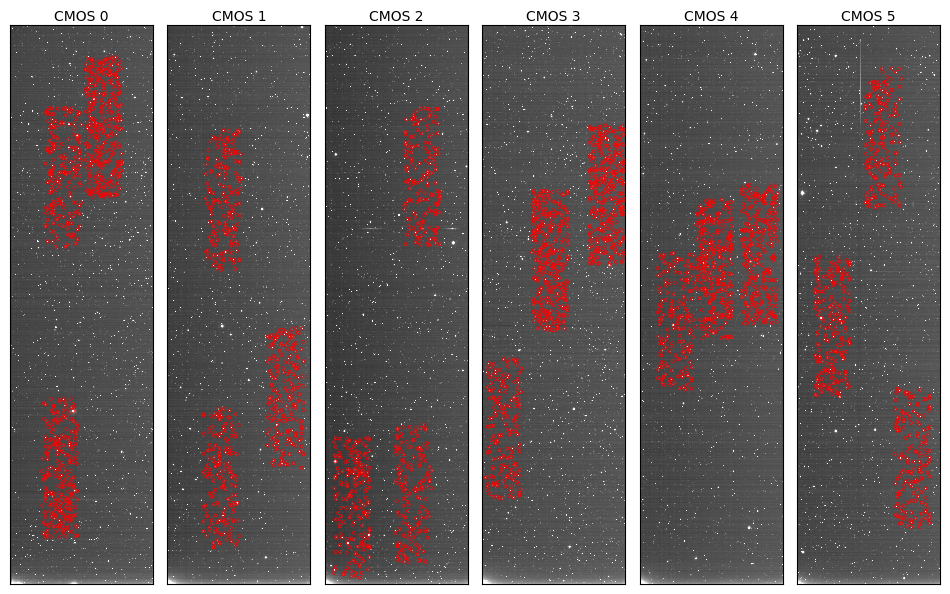

In [12]:
# 4x4 binning
show_focus_group_with_detections(
    images_dict,
    det_results_patch,
    "00012",
    vmin=75,
    vmax=150,
    s=5,
    bin_factor=8,
)


In [13]:
import pandas as pd
import numpy as np

def input_focus_positions(images_dict, save_csv="focus_meta.csv"):
    """
    images_dict の key（例 "00002"）ごとに、
    アクチュエータ距離 a,b,c を入力させて dict を返す。

    CSV を読み込むか確認し、
    無い場合は手動入力して、最後に CSV へ保存する。
    """

    print("\n=== Focusing Position Input ===\n")

    ans = input("Do you have an actuator CSV already? (y/n): ").strip().lower()

    focus_meta = {}

    # ======================================================
    # 1) CSV 読み込みモード
    # ======================================================
    if ans == "y":
        csv_path = input("Enter CSV filename (default: focus_meta.csv): ").strip()
        if csv_path == "":
            csv_path = save_csv

        try:
            # group_id を文字列として読み込む
            df = pd.read_csv(csv_path, dtype={"group_id": str})

            # index 指定されていたら読み替え
            if "group_id" in df.columns:
                df = df.set_index("group_id")

            # index を必ず文字列として扱う
            df.index = df.index.astype(str)

            focus_meta = df.to_dict(orient="index")

            # ave が無い場合の計算
            for gid in focus_meta:
                a = focus_meta[gid].get("a", np.nan)
                b = focus_meta[gid].get("b", np.nan)
                c = focus_meta[gid].get("c", np.nan)
                focus_meta[gid]["ave"] = np.nanmean([a, b, c])

            print("\n=== Loaded CSV Successfully ===\n")

        except Exception as e:
            print(f"\n!! Failed to load CSV: {e}")
            print("Switching to manual input mode...\n")
            focus_meta = {}

    # ======================================================
    # 2) CSV に無い group_id を手動入力で補完
    # ======================================================
    print("Checking for missing group IDs...")
    all_groups = sorted(images_dict.keys())

    for gid in all_groups:

        # 文字列として統一
        gid = str(gid)

        if gid in focus_meta:
            # 既にある場合はスキップ
            continue

        print(f"\n--- Group ID {gid} is missing. Enter actuator positions manually. ---")

        def ask_float(name):
            val = input(f"  {name} distance (mm): ")
            return float(val) if val.strip() != "" else np.nan

        a = ask_float("a")
        b = ask_float("b")
        c = ask_float("c")

        ave = np.nanmean([a, b, c])

        focus_meta[gid] = {
            "a": a,
            "b": b,
            "c": c,
            "ave": ave,
        }

    print("\n=== All group IDs completed ===\n")

    # ======================================================
    # 3) CSV 保存（手動入力した場合も、CSV読込した場合も保存しておく）
    # ======================================================
    print(f"Saving to CSV: {save_csv}")

    # dict → DataFrame
    df = pd.DataFrame.from_dict(focus_meta, orient="index")

    df.index.name = "group_id"
    df.to_csv(save_csv)

    print("Saved.\n")

    return focus_meta


In [14]:
focus_meta = input_focus_positions(images_dict)


=== Focusing Position Input ===



Do you have an actuator CSV already? (y/n):  y
Enter CSV filename (default: focus_meta.csv):  focus_meta.csv



=== Loaded CSV Successfully ===

Checking for missing group IDs...

=== All group IDs completed ===

Saving to CSV: focus_meta.csv
Saved.



In [15]:
from astropy.stats import SigmaClip
import numpy as np

# group_id → (CMOS_idx → {"mean": ..., "err": ...})
fwhm_map = {}

sigma_clip = SigmaClip(sigma=3.0, maxiters=5)  # パラメータは好みで

for gid, frames in det_results_patch.items():
    fwhm_map[gid] = {}
    for rec in frames:
        idx = rec["index"]      # CMOS番号
        df  = rec["table"]      # 検出天体テーブル

        vals = df["fwhm_arcsec"].values.astype(float)

        # NaN を一回落としておく（念のため）
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0:
            fwhm_map[gid][idx] = {"mean": np.nan, "err": np.nan}
            continue

        # --- sigma clip ---
        clipped = sigma_clip(vals)  # MaskedArray が返る
        good = clipped.data[~clipped.mask]

        if len(good) == 0:
            # クリップで全部飛んだ場合
            fwhm_map[gid][idx] = {"mean": np.nan, "err": np.nan}
            continue

        # クリップ後の平均
        mean_fwhm = np.mean(good)
        ave_fwhm = np.average(good)

        # 誤差（標準誤差）: σ / √N
        if len(good) > 1:
            std_fwhm = np.std(good, ddof=1)
            err_fwhm = std_fwhm / np.sqrt(len(good))
        else:
            std_fwhm = 0.0
            err_fwhm = np.nan  # 1点だけなら誤差は定義しづらいので NaN にしておく

        fwhm_map[gid][idx] = {
            "mean": mean_fwhm,
            "err": err_fwhm,
            "ave": ave_fwhm,
        }


In [16]:
for gid, meta in focus_meta.items():
    a = meta.get("a", np.nan)
    b = meta.get("b", np.nan)
    c = meta.get("c", np.nan)
    meta["ave"] = np.nanmean([a, b, c])


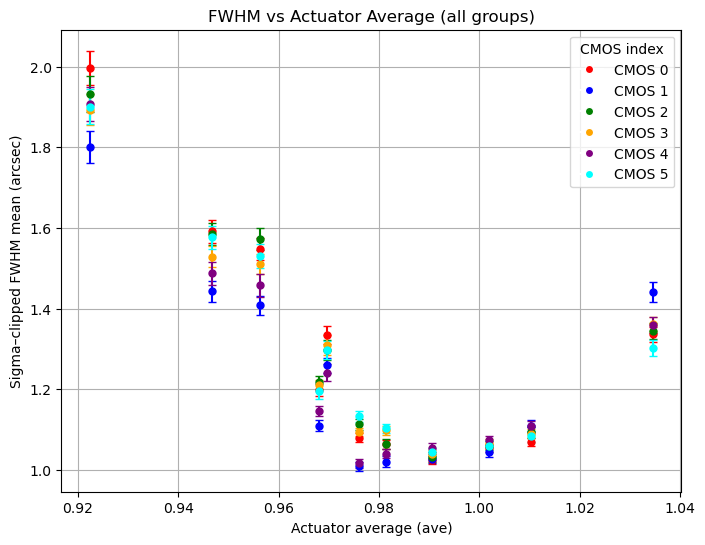

In [17]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["red","blue","green","orange","purple","cyan"]

plt.figure(figsize=(8,6))

for gid in fwhm_map.keys():

    # ave（アクチュエータ平均）
    ave = focus_meta[gid]["ave"]
    if np.isnan(ave):
        continue

    for cmos_idx, stats in fwhm_map[gid].items():
        mean_val = stats["mean"]
        err_val  = stats["err"]

        if np.isnan(mean_val):
            continue

        plt.errorbar(
            ave, mean_val,
            yerr=err_val,
            fmt='o',
            color=colors[cmos_idx % len(colors)],
            markersize=5,
            capsize=3,
        )

# 軸ラベルなど
plt.xlabel("Actuator average (ave)")
plt.ylabel("Sigma–clipped FWHM mean (arcsec)")
plt.title("FWHM vs Actuator Average (all groups)")
plt.grid(True)

# 凡例（CMOSごと）
handles = [plt.Line2D([0],[0], marker='o', color='w',
            markerfacecolor=colors[i], markersize=6, label=f"CMOS {i}")
           for i in range(len(colors))]
plt.legend(handles=handles, title="CMOS index")

plt.show()


CMOS 0: best focus ≈ 0.999 (ave), FWHM ≈ 1.072 arcsec
CMOS 1: best focus ≈ 0.991 (ave), FWHM ≈ 1.062 arcsec
CMOS 2: best focus ≈ 0.999 (ave), FWHM ≈ 1.090 arcsec
CMOS 3: best focus ≈ 0.998 (ave), FWHM ≈ 1.096 arcsec
CMOS 4: best focus ≈ 0.995 (ave), FWHM ≈ 1.064 arcsec
CMOS 5: best focus ≈ 1.001 (ave), FWHM ≈ 1.090 arcsec


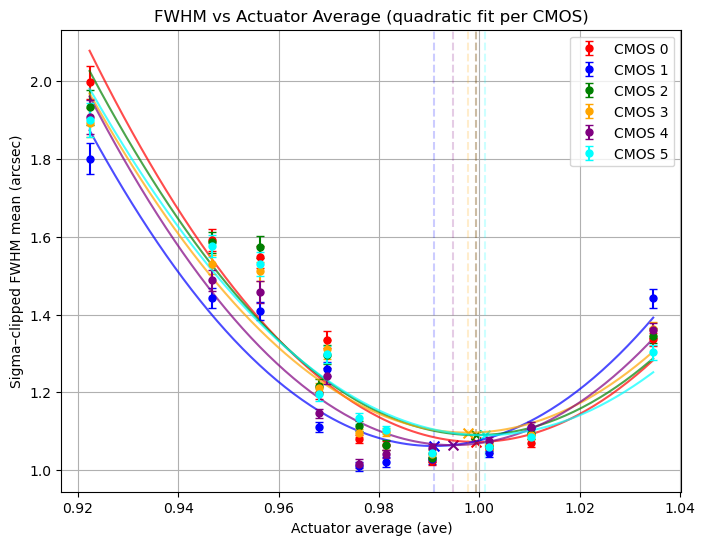

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

colors = ["red", "blue", "green", "orange", "purple", "cyan"]

# まず CMOSごとに (ave, mean_fwhm, err) を集約する
cmos_data = defaultdict(lambda: {"x": [], "y": [], "yerr": []})

for gid, cmos_dict in fwhm_map.items():

    # ave（アクチュエータ平均）
    ave = focus_meta[gid]["ave"]
    if np.isnan(ave):
        continue

    for cmos_idx, stats in cmos_dict.items():
        mean_val = stats["mean"]
        err_val  = stats["err"]

        if np.isnan(mean_val):
            continue

        cmos_data[cmos_idx]["x"].append(ave)
        cmos_data[cmos_idx]["y"].append(mean_val)
        cmos_data[cmos_idx]["yerr"].append(err_val)

plt.figure(figsize=(8, 6))

best_focus_results = {}  # CMOSごとの best focus を保存しておく

for cmos_idx, d in cmos_data.items():
    x = np.array(d["x"])
    y = np.array(d["y"])
    yerr = np.array(d["yerr"])

    if len(x) == 0:
        continue

    # x で並べ替え（フィット & プロットをきれいにするため）
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    yerr = yerr[order]

    color = colors[cmos_idx % len(colors)]

    # --- 散布図 + エラーバー ---
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt='o',
        color=color,
        markersize=5,
        capsize=3,
        label=f"CMOS {cmos_idx}",
    )

    # --- 2次関数でフィット ---
    if len(x) >= 3:
        # y ≈ a x^2 + b x + c
        coef = np.polyfit(x, y, deg=2)
        a, b, c = coef

        # 高密度な x で滑らかな曲線を描画
        x_dense = np.linspace(x.min(), x.max(), 200)
        y_dense = np.polyval(coef, x_dense)
        plt.plot(x_dense, y_dense, color=color, alpha=0.7)

        # 頂点（best focus）: x_best = -b / (2a)
        if a != 0:
            x_best = -b / (2.0 * a)
            y_best = np.polyval(coef, x_best)

            best_focus_results[cmos_idx] = (x_best, y_best)

            # グラフ上にマーカーと縦線を入れる
            if x.min() <= x_best <= x.max():
                plt.axvline(x_best, color=color, alpha=0.2, linestyle='--')
            plt.scatter([x_best], [y_best], color=color, marker='x', s=50)

            print(f"CMOS {cmos_idx}: best focus ≈ {x_best:.3f} (ave), FWHM ≈ {y_best:.3f} arcsec")
        else:
            print(f"CMOS {cmos_idx}: quadratic fit has a=0, cannot compute vertex.")
    else:
        # 点が少ないと 2次フィットは不安定なので、その場合は線形だけでもOK
        if len(x) >= 2:
            coef = np.polyfit(x, y, deg=1)
            x_dense = np.linspace(x.min(), x.max(), 200)
            y_dense = np.polyval(coef, x_dense)
            plt.plot(x_dense, y_dense, color=color, alpha=0.7)

plt.xlabel("Actuator average (ave)")
plt.ylabel("Sigma–clipped FWHM mean (arcsec)")
plt.title("FWHM vs Actuator Average (quadratic fit per CMOS)")
plt.grid(True)
plt.legend()
plt.show()
